# TF-MInDi Tutorial 2: Analysis and Clustering

This tutorial covers the analysis steps of TF-MInDi:
- Clustering seqlets with different resolutions
- Evaluating clustering quality
- Iterative refinement and filtering
- Generating motif patterns using {func}`tfmindi.tl.create_patterns` from clusters

**Prerequisites**: Complete [01_preprocessing_tutorial.ipynb](01_preprocessing_tutorial.ipynb) first.
**Next steps**: Continue with [03_visualization_tutorial.ipynb](03_visualization_tutorial.ipynb) for plotting and interpretation.

In [1]:
import tfmindi as tm

DATA_DIR = "../../../../data/tfmindi/"

# Load preprocessed data from previous tutorial
adata = tm.load_h5ad(DATA_DIR + "seqlets.h5ad")

To cluster the seqlets, we use {func}`tfmindi.tl.cluster_seqlets`.  

This function performs the following steps:
1. PCA on similarity matrix
2. Compute neighborhood graph
3. Generate t-SNE embedding
4. Leiden clustering at specified resolution
5. Calculate mean contribution scores from stored seqlet matrices
6. Assign DBD annotations based on top motif similarity per seqlet
7. Map leiden clusters to consensus DBD annotations

In [2]:
tm.tl.cluster_seqlets(adata, resolution=3.0)

Computing PCA...


Computing neighborhood graph...


/home/VIB.LOCAL/lukas.mahieu/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Computing t-SNE embedding...
Performing Leiden clustering with resolution 3.0...
Clustering complete. Found 89 clusters.
DBD annotation coverage: 1007193/1007193 seqlets


This not only clustered the seqlets, but, if you have DBD annotations in your anndata, it will have assigned each cluster to a major TF-family (based on the most common annotation per cluster. If the most common are NaNs, then the cluster will be NaN).  
This info is located in the `Anndata.obs["cluster_dbd"]`. We will use this column in our plotting to visualize the seqlet patterns.

In [3]:
adata.obs["cluster_dbd"].value_counts()

cluster_dbd
C2H2 ZF                    184001
Homeodomain                138362
bHLH                       119109
Nuclear receptor            89522
Forkhead                    75456
bZIP                        72085
HMG/Sox                     63434
GATA                        59383
Ets                         49074
C2H2 ZF; Homeodomain        36466
Homeodomain; Paired box     29530
Homeodomain; POU            22226
SMAD                        19480
CUT; Homeodomain            18291
TBP                         14272
RFX                         12764
TEA                          2351
IRF                           966
Myb/SANT                      421
Name: count, dtype: int64

In [4]:
# count number of NaNs (clusters where the majority of seqlets do not have a DBD annotation)
print(adata.obs["cluster_dbd"].isna().sum(), "NaN values")

0 NaN values


## Plotting our first round of clustering

We strongly recommend to visualize the average contribution of each seqlet. Noisy seqlets will have a low contribution and are often localized in the middle of the tSNE.

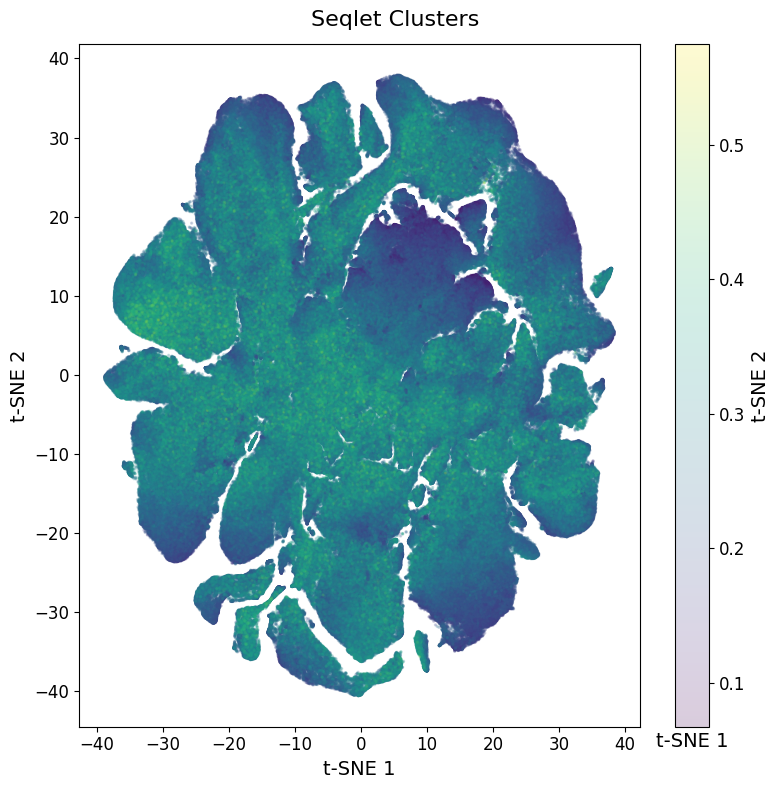

In [5]:
%matplotlib inline
tm.pl.tsne(
    adata,
    color_by="mean_contrib",
    s=2,
    alpha=0.2,
    save_path=DATA_DIR + "seqlets_tsne_mean_contrib.png",
)

We can also visualize the TF family annotation, noisy seqlet clusters won't have a TF annotation based on majority voting and will thus be annotated as "Unknown".

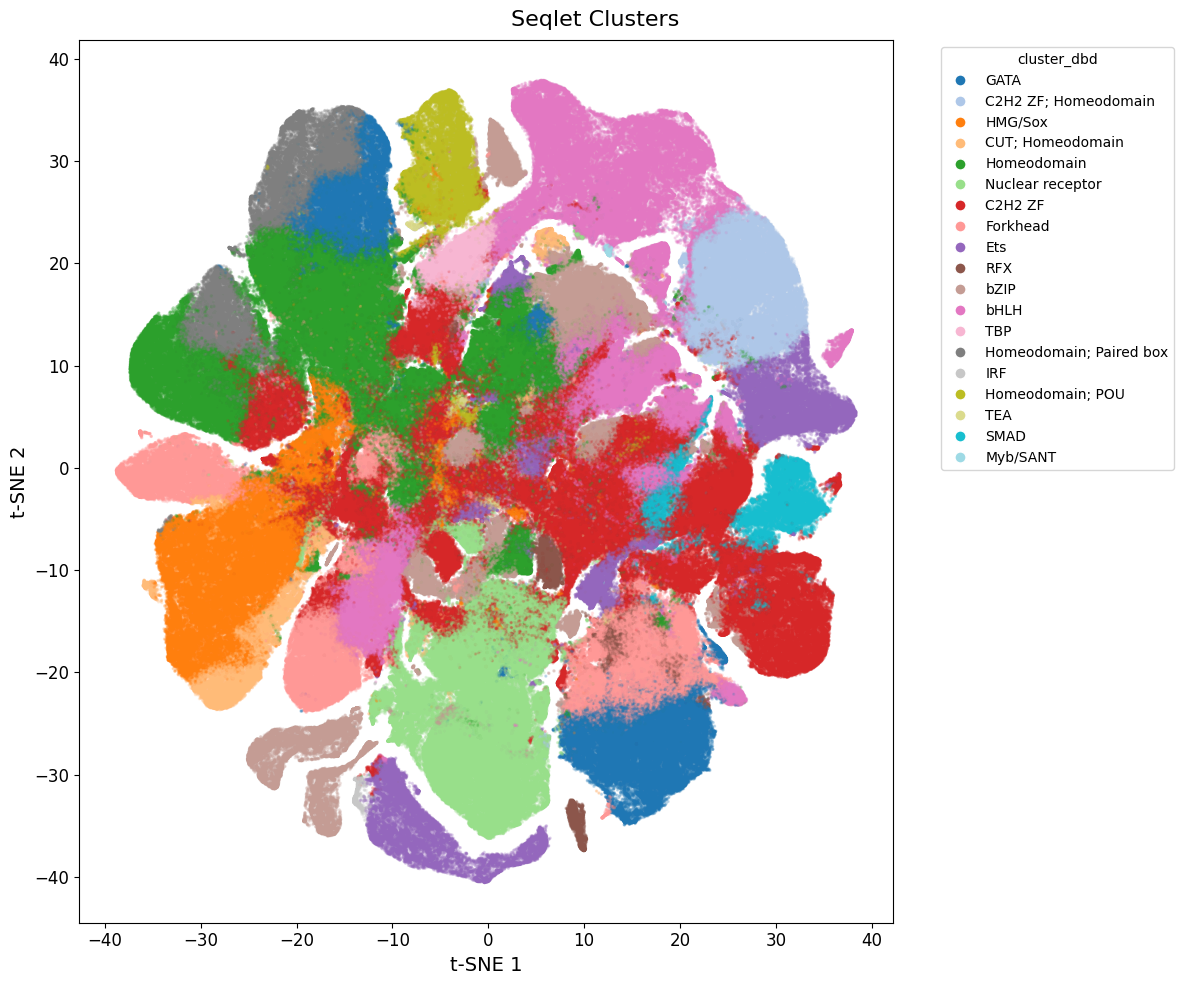

In [6]:
tm.pl.tsne(
    adata,
    color_by="cluster_dbd",
    width=12,
    height=10,
    s=2,
    alpha=0.2,
    save_path=DATA_DIR + "seqlets_tsne_cluster_dbd.png",
)

In [ ]:
adata.obs["total_sim"] = adata.X.sum(axis=1)
adata.obs

,example_idx,start,end,attribution,p-value,seqlet_matrix,seqlet_oh,example_oh_idx,example_contrib_idx,cell_type,leiden,mean_contrib,seqlet_dbd,cluster_dbd,total_sim
0,19895,1096,1125,45.111572,4.839551e-11,"[[-0.08926727, -0.10968999, -0.15208726, 0.163...","[[0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0,...",0,0,Oligo,0,0.266983,Rel,GATA,281.028290
1,18255,1020,1043,-34.561593,1.637069e-07,"[[0.15715095, -0.033791617, 0.056597892, 0.021...","[[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0,...",1,1,Oligo,20,0.109079,NaN,C2H2 ZF; Homeodomain,397.123535
2,19577,1067,1097,44.328660,3.006946e-07,"[[-0.010883039, -0.07761465, 0.06216719, 0.059...","[[0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0,...",2,2,Oligo,16,0.205674,NaN,HMG/Sox,368.301941
3,19470,1012,1042,42.433888,3.238232e-07,"[[0.033189923, 0.011888067, -0.03558427, -0.02...","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0,...",3,3,Oligo,18,0.208381,NaN,CUT; Homeodomain,414.876526
4,18418,1033,1050,25.828063,3.966867e-07,"[[0.06511731, 0.031657185, -0.1885347, -0.2174...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",4,4,Oligo,18,0.167479,NaN,CUT; Homeodomain,447.839355
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1007188,28553,1185,1197,0.937242,4.933225e-02,"[[-0.18672404, -0.007951359, -0.26221648, -0.0...","[[1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0,...",22469,22469,L5ET,33,0.270721,NaN,Homeodomain; POU,235.732681
1007189,31960,1133,1145,0.492551,4.933225e-02,"[[-0.33120006, -0.08518704, -0.10304987, -0.09...","[[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0,...",4376,4376,L5_6NP,1,0.308026,NaN,bHLH,182.217789
1007190,14609,1001,1013,1.563974,4.933225e-02,"[[-0.2142288, -0.15257195, -0.064200394, 0.291...","[[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0,...",22155,22155,Sst,7,0.232398,Homeodomain; POU,Homeodomain; POU,215.940689
1007191,5074,1073,1085,0.836284,4.933225e-02,"[[-0.10169616, -0.21603741, 0.1360202, 0.59914...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",23419,23419,Micro_PVM,83,0.272295,Ets,Ets,428.042267


In [25]:
adata.obs["max_sim"] = adata.X.max(axis=1).todense()

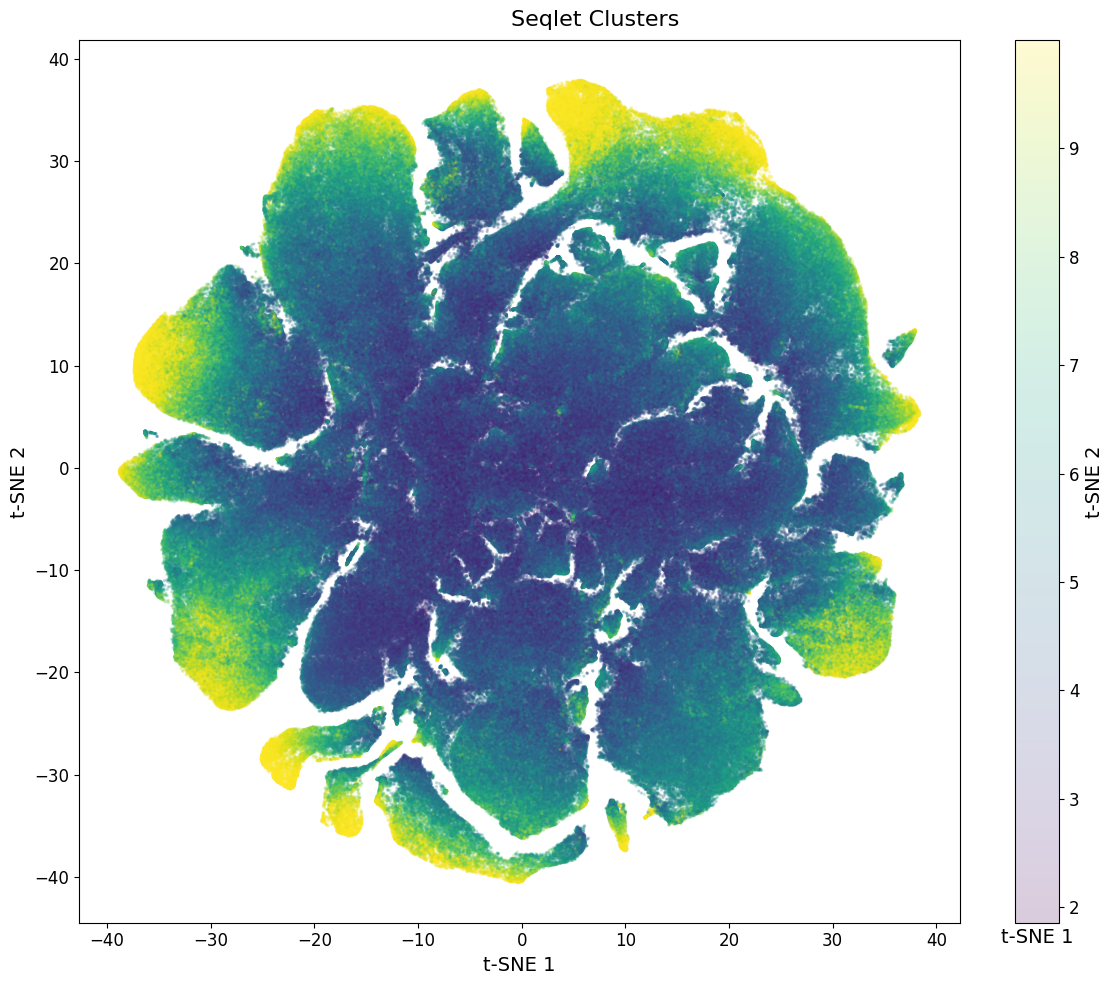

In [26]:
tm.pl.tsne(
    adata,
    color_by="max_sim",
    width=12,
    height=10,
    s=2,
    alpha=0.2,
    save_path=DATA_DIR + "seqlets_tsne_cluster_dbd.png",
)

In [32]:
tm.save_h5ad(adata, DATA_DIR + "seqlets_clustered.h5ad")

## Second round of clustering

Since we had a fairly strict significance threshold when calling our seqlets (0.05) and our cluster resolution was quite low, we don't have many "Unknown" seqlets clusters.  
Yet, it's still a good idea to omit the clusters that weren't annotated and perform clustering again on this "denoised" dataset. We'll also recluster with a higher resolution to get more fine-grained clusters.   

In [33]:
adata = tm.load_h5ad(DATA_DIR + "seqlets_clustered.h5ad")

In [34]:
adata_no_na = adata[~adata.obs["cluster_dbd"].isna()].copy()

In [35]:
print(f"Ommitting {adata.shape[0] - adata_no_na.shape[0]} seqlets without DBD annotation")

Ommitting 17 seqlets without DBD annotation


In [36]:
tm.tl.cluster_seqlets(adata_no_na, resolution=20.0)  # higher resolution to get more fine-grained clusters

Computing PCA...
Computing neighborhood graph...
Computing t-SNE embedding...
Performing Leiden clustering with resolution 20.0...
Clustering complete. Found 448 clusters.
DBD annotation coverage: 1001933/1007176 seqlets


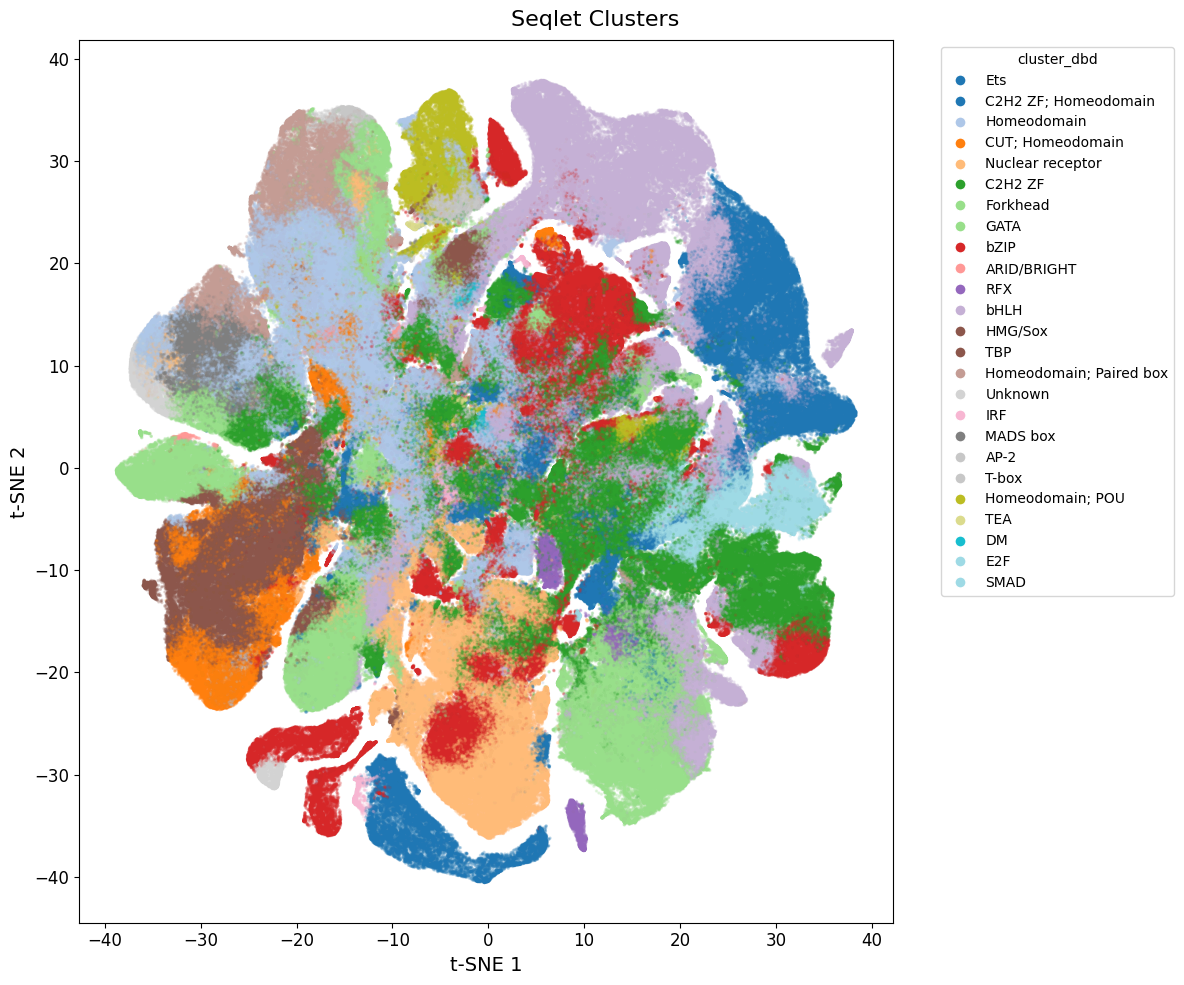

In [37]:
tm.pl.tsne(adata_no_na, color_by="cluster_dbd", width=12, height=10, s=2, alpha=0.2)

In [38]:
tm.save_h5ad(adata_no_na, DATA_DIR + "seqlets_clustered_no_na.h5ad")

## Generating Logos per cluster

Next, we will generate a logo for each cluster of seqlets. For this seqlets per cluster will be aligned using tomtom

In [2]:
adata_no_na = tm.load_h5ad(DATA_DIR + "seqlets_clustered_no_na.h5ad")

In [ ]:
patterns = tm.tl.create_patterns(
    adata_no_na,
    max_n=500,  # sample n seqlets per cluster to speed things up
)

Creating patterns for 448 clusters...


These logo's can now be visualized. For example, on top of the tSNE of seqlets.

In [15]:
# example pattern associated with cluster 72
patterns["72"]

Pattern(cluster=72, n_seqlets=466, len=19, consensus='ATTATGGTCAAGATGTAAA', mean_ic=0.47, dbd=Nuclear receptor)

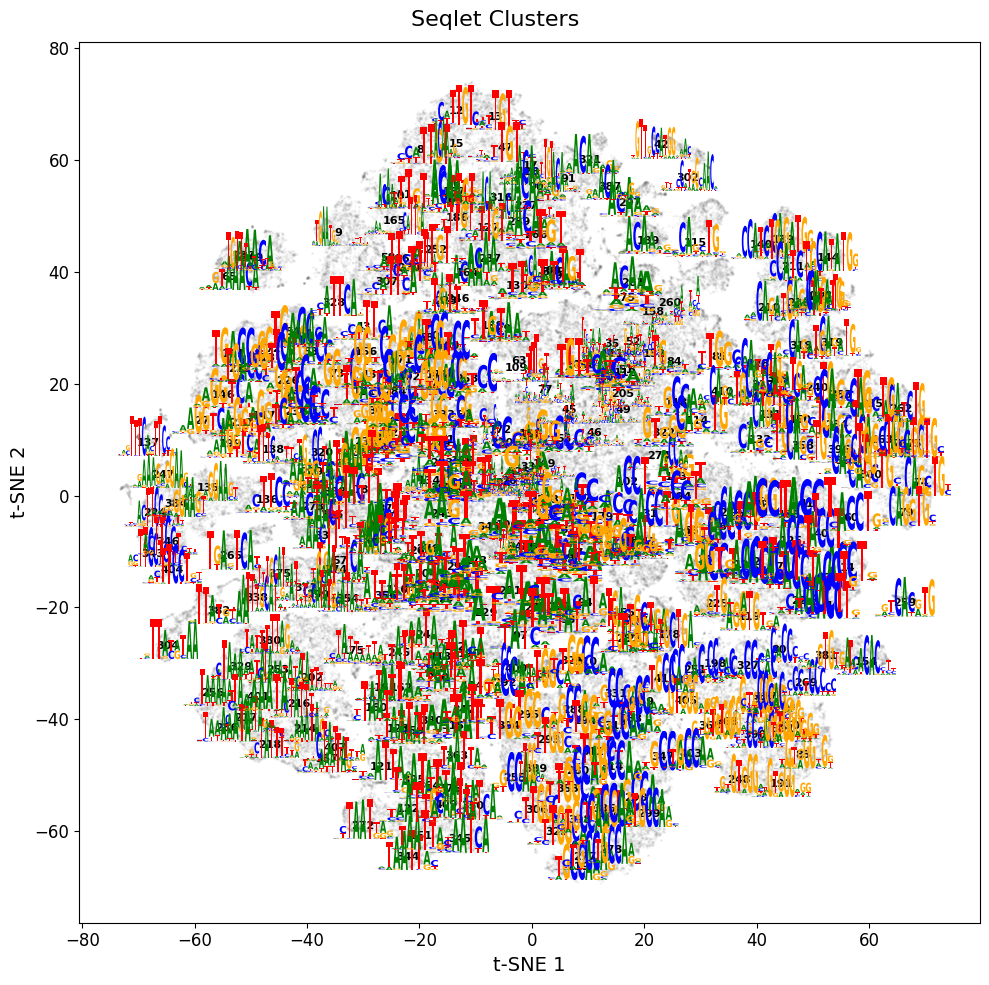

In [ ]:
tm.pl.tsne_logos(
    adata_no_na,
    patterns,
    gray_background=True,  # ignore cmap and make all points gray for better visibility
    min_nucleotides=4,  # ignore trimmed patterns less than 4 nucleotides (heterogeneous clusters)
    width=10,
    height=10,
    s=0.5,
    alpha=0.05,
    logo_height=0.2,
    logo_width=0.4,
    ic_threshold=0.2,  # nucleotides in pattern below this will be trimmed
)

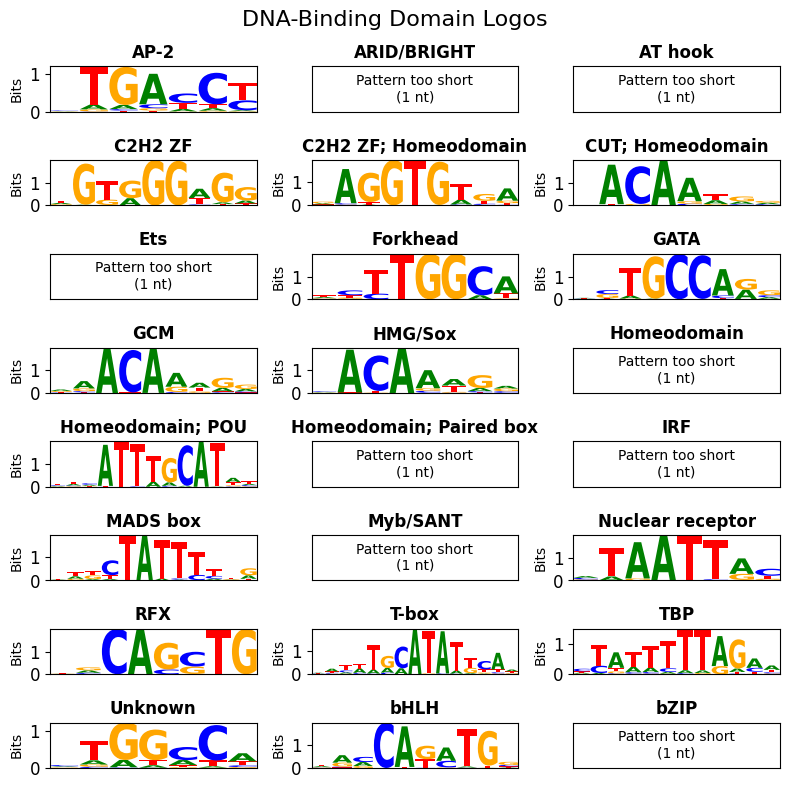

In [17]:
tm.pl.dbd_logos(patterns, ncols=3)

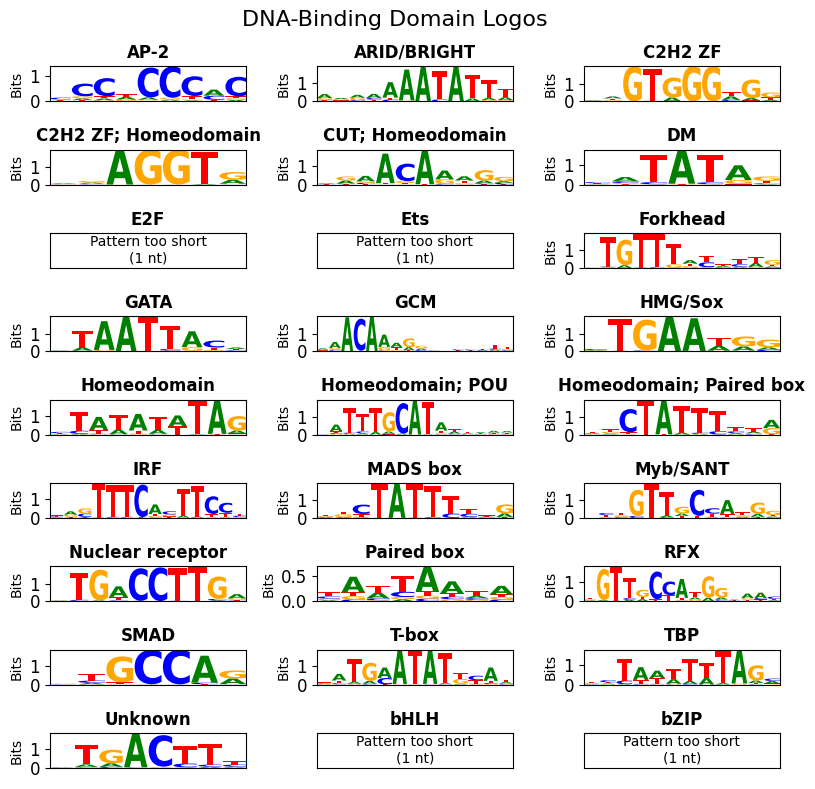

In [27]:
tm.pl.dbd_logos(patterns, ncols=3)

## Understanding Clustering Parameters

### Resolution Parameter

The **resolution** parameter controls cluster granularity:
- **Low values (0.1-1.0)**: Fewer, larger clusters - good for broad TF families
- **High values (5.0-20.0)**: Many small clusters - good for specific binding sites

### Choosing Resolution

1. **Start moderate** (1.0-3.0) for initial exploration
2. **Check cluster quality** using mean contribution and DBD annotations
3. **Filter noise** by removing clusters with unknown DBDs
4. **Increase resolution** on cleaned data for fine-grained analysis

### Quality Metrics to Consider

- **Mean contribution**: Higher = less noisy seqlets
- **DBD annotation coverage**: More annotations = better clusters
- **Cluster sizes**: Very small clusters may be artifacts
- **Pattern information content**: Higher IC = more specific motifs

In [ ]:
# Example: Test multiple resolutions
resolutions = [0.5, 1.0, 2.0, 5.0, 10.0]
for res in resolutions:
    adata_test = adata.copy()
    tm.tl.cluster_seqlets(adata_test, resolution=res)

    n_clusters = adata_test.obs["leiden"].nunique()
    mean_contrib = adata_test.obs["mean_contrib"].mean()
    dbd_coverage = (~adata_test.obs["cluster_dbd"].isna()).mean()

    print(
        f"Resolution {res:4.1f}: {n_clusters:3d} clusters, "
        f"mean_contrib={mean_contrib:.3f}, DBD_coverage={dbd_coverage:.1%}"
    )

## Pattern Generation Parameters

### {func}() Options

- **max_n**: Subsample clusters with >max_n seqlets (default: None). Use 100-500 for speed
- **min_seqlets**: Skip clusters with fewer seqlets (default: 10)
- **alignment_method**: How to align seqlets in cluster (default: "tomtom")

### When to Use Subsampling

- **Large clusters (>1000 seqlets)**: Use max_n=500 for speed
- **Initial exploration**: Use max_n=100 for quick preview
- **Final analysis**: Use max_n=None or high value for best patterns

In [ ]:
# Example: Pattern generation with different sampling strategies

# Quick preview (fast)
patterns_preview = tm.tl.create_patterns(adata_no_na, max_n=100)
print(f"Preview: {len(patterns_preview)} patterns generated quickly")

# Full analysis (slower but comprehensive)
# patterns_full = tm.tl.create_patterns(adata_no_na, max_n=None)
# print(f"Full: {len(patterns_full)} patterns with all seqlets")